In [1]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import shap
import lightgbm as lgb
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier


In [2]:
df=pd.read_csv("/workspaces/jovegom-intro-ml/data/bank-marketing-campaign-data.csv",sep=';')
df=df.rename(columns={'marital':'estado_civil','default':'tiene_credito','housing':'credito_vivienda','loan':'credito_persoanl','month':'ulti_mes_contac','day_of_week':'ultimo_dia_contac','duration':'duracion_contac','campaign':'n_contac','y':'deposito_largo_plazo'})

In [3]:
df

,age,job,estado_civil,education,tiene_credito,credito_vivienda,credito_persoanl,contact,ulti_mes_contac,ultimo_dia_contac,...,n_contac,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,deposito_largo_plazo
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


# Identificamos valores unicos

In [4]:
valores_unicos=df.nunique()
valores_unicos

age                       78
job                       12
estado_civil               4
education                  8
tiene_credito              3
credito_vivienda           3
credito_persoanl           3
contact                    2
ulti_mes_contac           10
ultimo_dia_contac          5
duracion_contac         1544
n_contac                  42
pdays                     27
previous                   8
poutcome                   3
emp.var.rate              10
cons.price.idx            26
cons.conf.idx             26
euribor3m                316
nr.employed               11
deposito_largo_plazo       2
dtype: int64

No tenemos valores unicos

# Filas y columnas duplicadas

In [5]:
# Filas duplicadas
df.duplicated().sum()

np.int64(12)

In [6]:
# Tenemos 12 duplicados los cuales eliminamos
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [7]:
df.T.duplicated().sum()

np.int64(0)

No tenemos columnas duplicadas

# Valores Faltantes

In [8]:
promedio_faltantes=df.isna().mean()*100
faltantes = ["no hay valores faltantes"] if any(n == 0 for n in promedio_faltantes) else promedio_faltantes
faltantes


['no hay valores faltantes']

## Valores faltantes enmascarados   

In [9]:
# traemos el Df con solo columnas categoricas
df_cate = df.select_dtypes(include=['object'])
# sacamos la cantidad de unknown por columna
unknown_counts = df_cate.apply(lambda col: (col == "unknown").sum())
# sacamos el porcentaje de unknown
unknown_porce= df_cate.apply(lambda col: (col == "unknown").mean()*100)
# creamos un DF con esta info
df_result=pd.DataFrame({'unknown_counts':unknown_counts,'unknown_porcentaje':unknown_porce}).sort_values(by='unknown_counts',ascending=False)
df_result

,unknown_counts,unknown_porcentaje
tiene_credito,8596,20.876239
education,1730,4.201477
credito_vivienda,990,2.404313
credito_persoanl,990,2.404313
job,330,0.801438
estado_civil,80,0.194288
contact,0,0.000000
ulti_mes_contac,0,0.000000
ultimo_dia_contac,0,0.000000
poutcome,0,0.000000


deacuerdo a lo anterior se decide eliminar los datos que tienen menos del 1% y se pone en consideracion mas adelante los que tienen un 2.4%

In [10]:
df_cate = df.select_dtypes(include=['object'])
# sacamos la cantidad de unknown por columna
nonexistent_counts = df_cate.apply(lambda col: (col == "nonexistent").sum())
# sacamos el porcentaje de unknown
nonexistent_porce= df_cate.apply(lambda col: (col == "nonexistent").mean()*100)
# creamos un DF con esta info
df_result=pd.DataFrame({'nonexistent_counts':nonexistent_counts,'nonexistent_porcentaje':nonexistent_porce}).sort_values(by='nonexistent_counts',ascending=False)
df_result

,nonexistent_counts,nonexistent_porcentaje
poutcome,35551,86.33913
estado_civil,0,0.00000
job,0,0.00000
education,0,0.00000
tiene_credito,0,0.00000
credito_persoanl,0,0.00000
credito_vivienda,0,0.00000
contact,0,0.00000
ulti_mes_contac,0,0.00000
ultimo_dia_contac,0,0.00000


Eliminamos la columna poutcome, ya que en su mayoria no posee datos que nos aporte al modelo

In [11]:
df = df.drop('poutcome', axis=1)

In [12]:
df=df[df['job']!='unknown']
df=df[df['estado_civil']!='unknown']
unknown_counts = df[['job','estado_civil']].apply(lambda col: (col == "unknown").sum())
unknown_counts

job             0
estado_civil    0
dtype: int64

<Axes: >

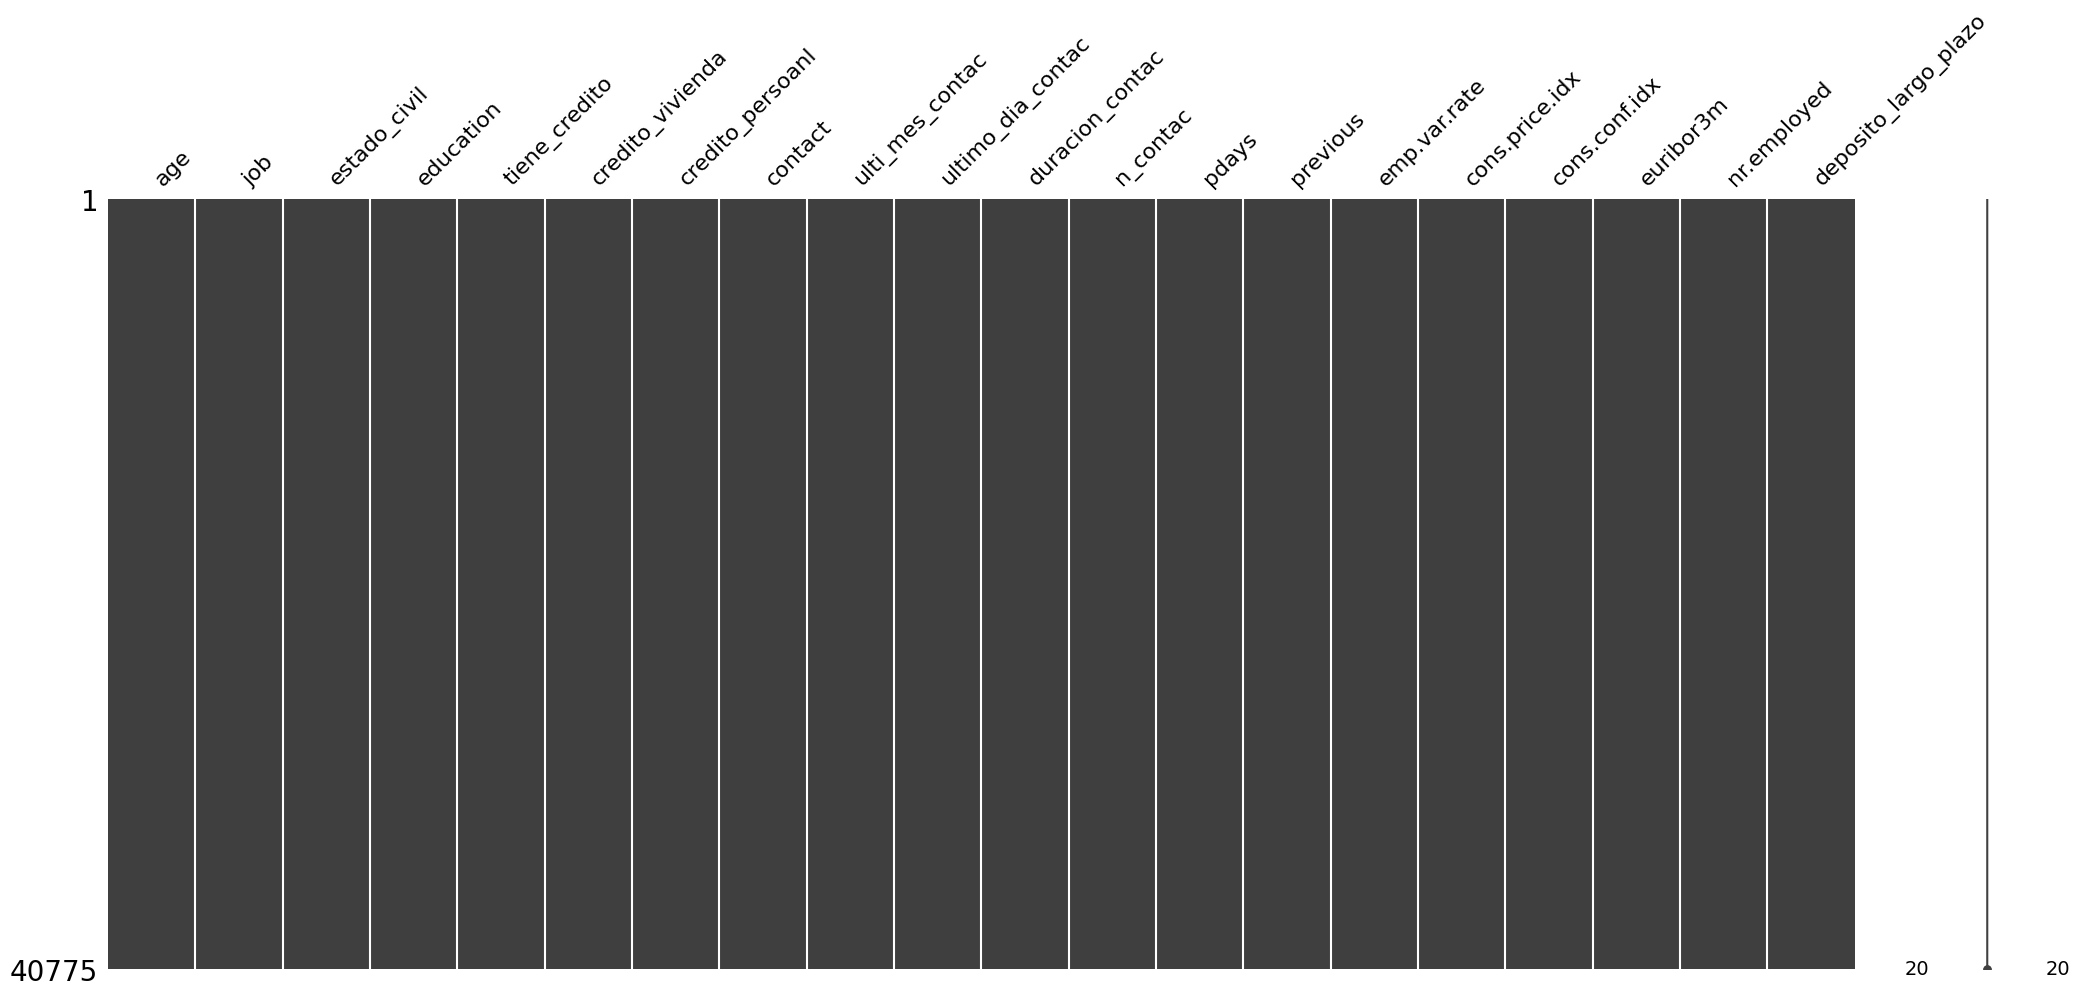

In [13]:
msno.matrix(df)

# Codificar variables categóricas.

In [14]:

# Identificar columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns

# Contar categorías por columna
num_categories = df[cat_cols].nunique()

# Dividir columnas según número de categorías
onehot_cols = num_categories[num_categories <= 4].index.tolist()
freq_cols   = num_categories[num_categories > 4].index.tolist()

# Aplicar one-hot encoding a las columnas pequeñas
df_onehot = pd.get_dummies(df[onehot_cols], drop_first=True, dtype=int)

# Aplicar frequency encoding a las columnas grandes
df_freq = df[freq_cols].copy()
for col in df_freq.columns:
    freq = df_freq[col].value_counts()
    df_freq[col] = df_freq[col].map(freq)

# Combinar todo con las columnas numéricas restantes
num_cols = df.select_dtypes(exclude=['object']).columns
df = pd.concat([df[num_cols], df_onehot, df_freq], axis=1)


# Train test split

In [15]:
X= df.drop('deposito_largo_plazo_yes',axis=1)
y= df['deposito_largo_plazo_yes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Outliers

In [16]:
pd.set_option('display.float_format', '{:.3f}'.format)
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32620.000,39.972,10.382,17.000,32.000,38.000,47.000,98.000
duracion_contac,32620.000,258.068,258.170,0.000,102.000,179.000,320.000,3785.000
n_contac,32620.000,2.576,2.763,1.000,1.000,2.000,3.000,56.000
pdays,32620.000,962.808,186.086,0.000,999.000,999.000,999.000,999.000
previous,32620.000,0.171,0.489,0.000,0.000,0.000,0.000,6.000
emp.var.rate,32620.000,0.084,1.570,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,32620.000,93.576,0.578,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,32620.000,-40.526,4.625,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,32620.000,3.622,1.734,0.634,1.344,4.857,4.961,5.045
nr.employed,32620.000,5167.191,72.170,4963.600,5099.100,5191.000,5228.100,5228.100


In [17]:
iso = IsolationForest(random_state=123)
df_num = X_train.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train)
df_num['outlier_flag'].value_counts()

outlier_flag
 1    22455
-1    10165
Name: count, dtype: int64

# Seleccion de caracteristicas

## Método 1 Feature importance de RF

In [18]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train, y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Convertir a DataFrame
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
# Calculamos la importancia acumulada
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()
df_rf_imp

,feature,rf_importance,rf_importance_acum
1,duracion_contac,31.233,31.233
8,euribor3m,11.353,42.587
0,age,9.425,52.012
9,nr.employed,5.667,57.679
19,job,5.067,62.746
20,education,4.417,67.163
2,n_contac,4.336,71.499
3,pdays,4.221,75.720
22,ultimo_dia_contac,3.988,79.708
21,ulti_mes_contac,2.860,82.569


## Metodo 2 Permutation/Shuffle importance

In [19]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBClassifier(objective='binary:logistic',random_state=42,use_label_encoder=False,eval_metric='logloss').fit(X_train1, y_train1)

# Realizamos 10 permutaciones por cada característica (se usa neg_mean_absolute_error)
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='accuracy')

df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:03:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,feature,perm_imp
1,duracion_contac,5.846
8,euribor3m,1.438
9,nr.employed,0.946
5,emp.var.rate,0.898
3,pdays,0.723
21,ulti_mes_contac,0.501
18,contact_telephone,0.400
0,age,0.333
20,education,0.305
19,job,0.241


## Metodo 3 SHAP

In [20]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMClassifier(random_state=42, n_jobs=-1).fit(X_train, y_train)

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val).values

imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

[LightGBM] [Info] Number of positive: 3651, number of negative: 28969
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 726
[LightGBM] [Info] Number of data points in the train set: 32620, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111925 -> initscore=-2.071225
[LightGBM] [Info] Start training from score -2.071225


 96%|=================== | 6269/6524 [00:15<00:00]       

,feature,shap_imp
1,duracion_contac,39.922
5,emp.var.rate,19.869
21,ulti_mes_contac,9.105
8,euribor3m,8.044
9,nr.employed,5.415
12,tiene_credito_unknown,2.798
6,cons.price.idx,2.477
18,contact_telephone,2.410
0,age,2.053
2,n_contac,1.669


## Union de metodos

In [21]:
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

,feature,rf_importance,rf_importance_acum,perm_imp,shap_imp
8,duracion_contac,31.233,31.233,5.846,39.922
13,euribor3m,11.353,42.587,1.438,8.044
0,age,9.425,52.012,0.333,2.053
16,nr.employed,5.667,57.679,0.946,5.415
14,job,5.067,62.746,0.241,0.787
9,education,4.417,67.163,0.305,0.798
15,n_contac,4.336,71.499,0.207,1.669
17,pdays,4.221,75.720,0.723,0.973
22,ultimo_dia_contac,3.988,79.708,0.201,1.091
21,ulti_mes_contac,2.860,82.569,0.501,9.105


# Caracteristicas seleccionadas

In [22]:
df_filt = df_importances[(df_importances['rf_importance']>=1)|(df_importances['perm_imp']>=1)|(df_importances['shap_imp']>=1)]
df_filt

,feature,rf_importance,rf_importance_acum,perm_imp,shap_imp
8,duracion_contac,31.233,31.233,5.846,39.922
13,euribor3m,11.353,42.587,1.438,8.044
0,age,9.425,52.012,0.333,2.053
16,nr.employed,5.667,57.679,0.946,5.415
14,job,5.067,62.746,0.241,0.787
9,education,4.417,67.163,0.305,0.798
15,n_contac,4.336,71.499,0.207,1.669
17,pdays,4.221,75.720,0.723,0.973
22,ultimo_dia_contac,3.988,79.708,0.201,1.091
21,ulti_mes_contac,2.860,82.569,0.501,9.105


## VIF

In [23]:
features = df_filt['feature']
features

8           duracion_contac
13                euribor3m
0                       age
16              nr.employed
14                      job
9                 education
15                 n_contac
17                    pdays
22        ultimo_dia_contac
21          ulti_mes_contac
10             emp.var.rate
1             cons.conf.idx
2            cons.price.idx
7      credito_vivienda_yes
18                 previous
5      credito_persoanl_yes
11     estado_civil_married
12      estado_civil_single
3         contact_telephone
19    tiene_credito_unknown
Name: feature, dtype: object

In [31]:
vif = pd.Series([variance_inflation_factor(X_train[features].corr().values, i) for i in range(X_train[features].corr().shape[1])], index=X_train[features].columns)
df_vif = pd.Series(vif, name='vif').reset_index().rename(columns={'index': 'feature'})
df_vif_filt=pd.merge(df_vif, df_filt, on='feature' ,how='inner')
df_vif_filt

,feature,vif,rf_importance,rf_importance_acum,perm_imp,shap_imp
0,duracion_contac,1.120,31.233,31.233,5.846,39.922
1,euribor3m,24899.163,11.353,42.587,1.438,8.044
2,age,3.193,9.425,52.012,0.333,2.053
3,nr.employed,8934.748,5.667,57.679,0.946,5.415
4,job,1.414,5.067,62.746,0.241,0.787
5,education,1.533,4.417,67.163,0.305,0.798
6,n_contac,2.077,4.336,71.499,0.207,1.669
7,pdays,6.014,4.221,75.720,0.723,0.973
8,ultimo_dia_contac,1.080,3.988,79.708,0.201,1.091
9,ulti_mes_contac,19.122,2.860,82.569,0.501,9.105


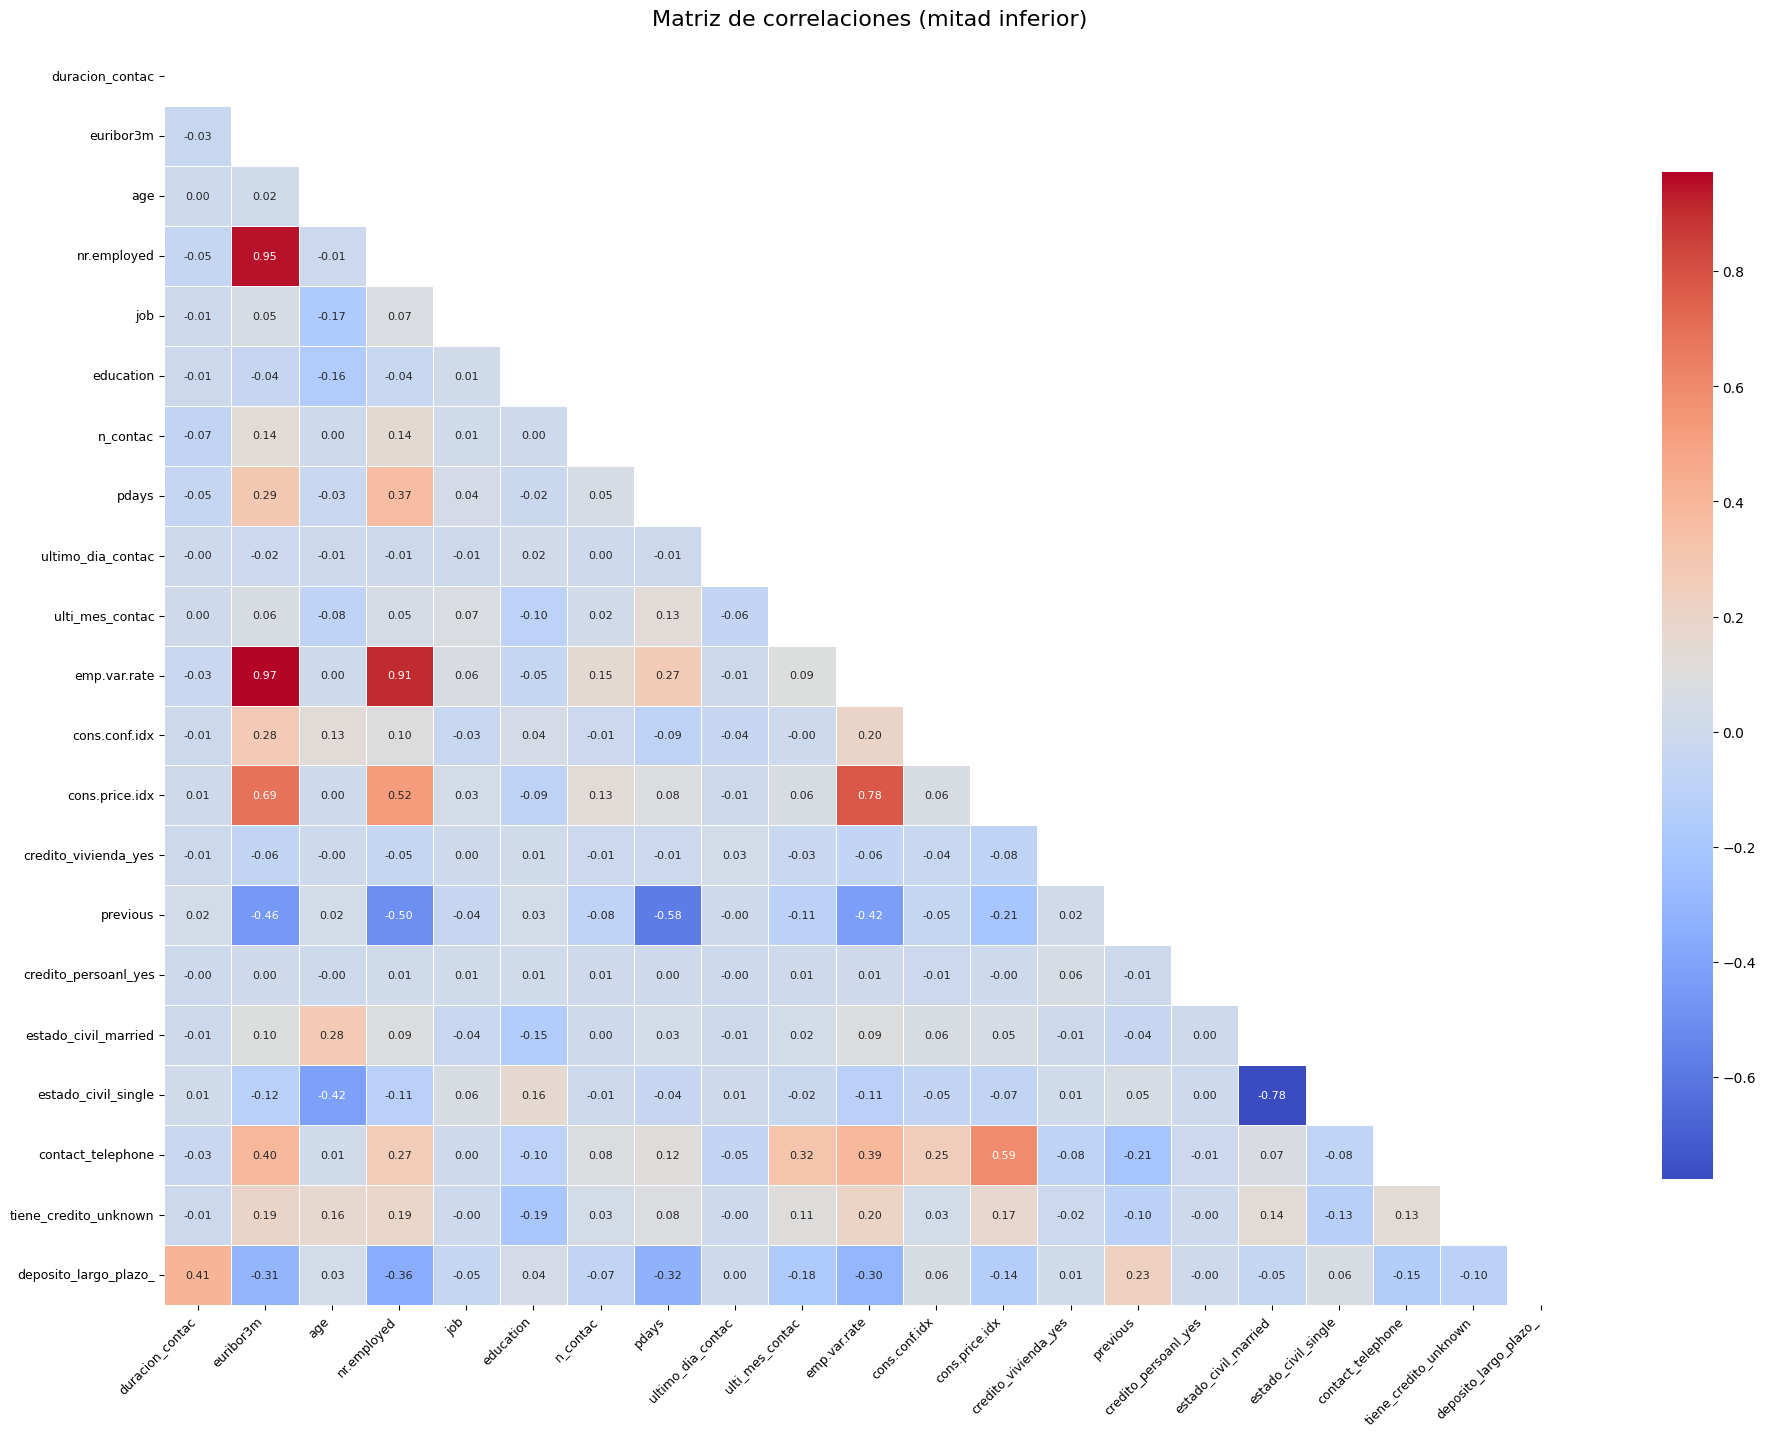

In [25]:
X_copy = X_train[features].copy()
X_copy['deposito_largo_plazo_'] = y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

## Cross_validation

In [26]:
# Versión 1: Realizar cross_validation con todas las características que son candidatas
cv_results1 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), X_train[features], y_train, cv=3, scoring='accuracy')
cv_results1.mean()*1

np.float64(0.9153586435480454)

In [40]:
# Versión 2: Realizar cross_validation con  las características que son candidatas sin las correlacionadas
cv_results2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), X_train[features].drop(['emp.var.rate','cons.price.idx','cons.conf.idx',],axis=1), y_train, cv=3, scoring='accuracy')
cv_results2.mean()*1

np.float64(0.9159411176923343)

In [38]:
# Versión 3: Realizar cross_validation con  las características que son candidatas sin las correlacionadas cons.price.idx
cv_results3 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), X_train[features].drop(['ulti_mes_contac'],axis=1), y_train, cv=3, scoring='accuracy')
cv_results3.mean()*1

np.float64(0.9155732424014743)

Al realizar el Croos validation vemos que el error promedio % es menor cuando no se elimina emp.var.rate la cual es una variable que guarda una alta correlacion con otras, sin embargo la dejamos por el resultado obtenido .

In [45]:
# Suponiendo que tu df se llama df_imp
df_vif_filt['mean_imp'] = df_vif_filt[['rf_importance','perm_imp','shap_imp']].mean(axis=1)

# Ordenamos de mayor a menor importancia
df_vif_filt_sorted = df_vif_filt.sort_values('mean_imp', ascending=False)

# Creamos la lista de features ordenada
features_sorted = df_vif_filt_sorted['feature'].tolist()
results = []
for i in range(3, len(features_sorted)+1):  # desde 3 features hasta todas
    feats = features_sorted[:i]
    model = RandomForestClassifier(random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X[feats], y, cv=3, scoring='accuracy')
    results.append({'n_features': i, 'features': feats, 'mean_accuracy': scores.mean()})
    
df_cv = pd.DataFrame(results)

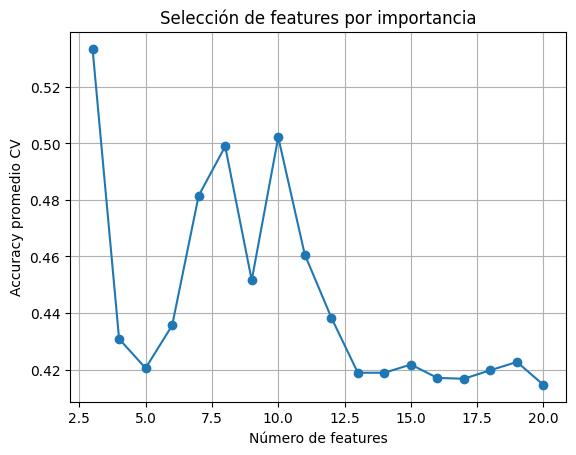

In [46]:
plt.plot(df_cv['n_features'], df_cv['mean_accuracy'], marker='o')
plt.xlabel("Número de features")
plt.ylabel("Accuracy promedio CV")
plt.title("Selección de features por importancia")
plt.grid(True)
plt.show()